# ELIZA

---------------

* Artificial Intelligence    

* Simulation                  

Index
1. Introduction
2. Script Data
3. Process
    1. Parse Words
    2. Pre Substitution (PRES)
    3. Emotional Quota (SYNONS)
        1. LSTMNN (5 CAT)
        2. SYNONS (CVS) 
    4. Analyze Keywords (KEYWORDS)
        1. Rank
        2. Decompilation
        3. Reassembly 
    5. Post Substitution (REFLECTIONS)
4. Feedforward


Eliza reads a line at a time from the user, processes it, and formulates a reply.

Processing consists of the following steps

1. First the sentence broken down into words, separated by spaces.  All further
processing takes place on these words as a whole, not on the individual
characters in them.

2. Second, a set of pre-substitutions takes place.

3. Third, Eliza takes all the words in the sentence and makes a list of all
keywords it finds.  It sorts this keyword list in descending weight.  It
process these keywords until it produces an output.

4. Fourth, for the given keyword, a list of decomposition patterns is searched.
The first one that matches is selected.  If no match is found, the next keyword
is selected instead.

5. Fifth, for the matching decomposition pattern, a reassembly pattern is
selected.  There may be several reassembly patterns, but only one is used
for a given sentence.  If a subsequent sentence selects the same decomposition
pattern, the next reassembly pattern in sequence is used, until they have all
been used, at which point Eliza starts over with the first reassembly pattern.

6. Sixth, a set of post-substitutions takes place.

7. Finally, the resulting sentence is displayed as output.

* **initial**:	Eliza says this when it starts.

* **final**:		Eliza says this when it quits.

* **quit**:		If the input is this, then Eliza quits.  Any number permitted.

* **pre**:		Part of the pre-substitution list.  If the first word appears in 
the sentence, it is replaced by the rest of the words.

* **post**:		Part of the post-subsititution list.  If the first word appears 
in the sentence, it is replaced by the rest of the words.

* **key**:		A keyword.  Keywords with greater weight are selected in 
preference to ones with lesser weight.
If no weight is given, it is assumed to be 1.

* **decomp**:		A decomposition pattern.  The character * stands for any 
sequence of words.  

* **reasmb**:		A reassembly pattern.  A set of words matched by * in 
the decomposition pattern can be used as part of the reassembly.
For instance, (2) inserts the words matched by the second * 
in the decomposition pattern.
            
* **synon**:		A list of synonyms.  In a decomposition rule, for instance, @be
matches any of the words "be am is are was" because of the line:
"synon: be am is are was".  The match @be also counts as a *
in numbering the matches for use by reassembly rules.

Other Special Rules
If a $ appears first in a decomposition rule, then the output is formed as
normal, but is saved and Eliza goes on to the next keyword.  If no keywords
match, and there are saved sentences, one of them is picked at random and
used as the output, then it is discarded.
If there are no saved sentences, and no keywords match, then it uses the
keyword "xnone".

In [5]:
import sys
print(sys.executable)

/home/phantom/Documents/AI_env/bin/python


In [6]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [7]:
import pandas as pd
import numpy as np
import re
import random # No

import os, random, math
from sklearn.model_selection import train_test_split

# DL
import tensorflow as tf
import keras
import keras.backend as K
from keras.preprocessing.sequence import pad_sequences
from keras import Model
from keras.layers import Input, Embedding, Dropout, SpatialDropout1D, GlobalAveragePooling1D
from keras.layers import GlobalMaxPooling1D, Bidirectional, GRU, Activation, Dense
from keras.layers import Dot, Reshape, TimeDistributed, concatenate, BatchNormalization
from keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
import itertools

from tensorflow.keras.utils import to_categorical # convert to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D
from keras.layers import Flatten, Lambda, BatchNormalization
from keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import LearningRateScheduler, EarlyStopping, Callback
from keras.utils import plot_model

# Visualization
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML
import seaborn as sns
sns.set()

 
import socket
host_name = socket.gethostbyname(socket.gethostname())


# GLOBAL VARIABLES
EMB_SIZE = 320
statement = "「AI」- VERSION: 49.2.13 Q-System hosted on " + host_name + " connecting to D-Wave LEAP."

/tmp/ipykernel_25423/120441929.py:35: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [9]:
print(statement)

「AI」- VERSION: 49.2.13 Q-System hosted on 127.0.1.1 connecting to D-Wave LEAP.


In [10]:
# [defaults] 
endpoint = 'https://cloud.dwavesys.com/sapi' 
# [dw2000_2_1] 
client = 'qpu' 
token = 'ABC-123456789123456789123456789'
dwavesys_name = socket.gethostbyname('cloud.dwavesys.com')
print('「AI」- LOCATED: LEAP D-Wave 2000Q System v.2.1 : '+dwavesys_name+' ONLINE')

「AI」- LOCATED: LEAP D-Wave 2000Q System v.2.1 : 15.197.163.78 ONLINE


In [12]:
# 1.3 Configure TENSORFLOW GPU Options
import tensorflow as tf

config = tf.ConfigProto()
config.gpu_options.allow_growth = True
print(tf.test.gpu_device_name())
sess = tf.Session()

AttributeError: module 'tensorflow' has no attribute 'ConfigProto'

In [5]:
# 1.4 EXTENDED KERAS MODEL CHECKPOINT CALLBACK
class GetBest(Callback):
    def __init__(self, monitor='val_loss', verbose=0,
                 mode='auto', period=1):
        super(GetBest, self).__init__()
        self.monitor = monitor
        self.verbose = verbose
        self.period = period
        self.best_epochs = 0
        self.epochs_since_last_save = 0

        if mode not in ['auto', 'min', 'max']:
            warnings.warn('GetBest mode %s is unknown, '
                          'fallback to auto mode.' % (mode),
                          RuntimeWarning)
            mode = 'auto'

        if mode == 'min':
            self.monitor_op = np.less
            self.best = np.Inf
        elif mode == 'max':
            self.monitor_op = np.greater
            self.best = -np.Inf
        else:
            if 'acc' in self.monitor or self.monitor.startswith('fmeasure'):
                self.monitor_op = np.greater
                self.best = -np.Inf
            else:
                self.monitor_op = np.less
                self.best = np.Inf

    def on_train_begin(self, logs=None):
        self.best_weights = self.model.get_weights()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epochs_since_last_save += 1
        if self.epochs_since_last_save >= self.period:
            self.epochs_since_last_save = 0
            current = logs.get(self.monitor)
            if current is None:
                warnings.warn('\033[1;44m「AI」- CLEARED: Can pick best model only with %s available, '
                              'skipping. \033[0m' % (self.monitor), RuntimeWarning)
            else:
                if self.monitor_op(current, self.best):
                    if self.verbose > 0:
                        print('\033[1;42m「AI」- PASSED: Epoch %05d: %s improved from %0.5f to %0.5f,'
                              ' storing weights. \033[0m' % (epoch + 1, self.monitor, self.best,
                                 current))
                    self.best = current
                    self.best_epochs = epoch + 1
                    self.best_weights = self.model.get_weights()
                else:
                    if self.verbose > 0:
                        print('\033[1;41m「AI」- FAILED: Epoch %05d: %s did not improve \033[0m' %
                              (epoch + 1, self.monitor))

    def on_train_end(self, logs=None):
        if self.verbose > 0:
            print('\n\033[1;7m「AI」- LEVELED: Using epoch %05d with %s: %0.5f \033[0m' % 
                  (self.best_epochs, self.monitor, self.best))
        self.model.set_weights(self.best_weights)

In [6]:
# entries prestructured as layed out in Weizenbaum's description
# [cf: Communications of the ACM, Vol. 9, #1 (January 1966): p 36-45.]
# Eliza says this when it starts.
INITIALS = [
    "How do you do.  Please tell me your problem.",
    # additions (not original)
    "Please tell me what's been bothering you.",
    "Is something troubling you?",
    "「AI」: I am ready.",
    "「AI」: You have intruded upon the Mighty OZ... Please state your business..."
]

In [7]:
# Eliza says this when it quits.
FINALS = [
    "Goodbye.  It was nice talking to you.",
    # additions (not original)
    "Goodbye.  This was really a nice talk.",
    "Goodbye.  I'm looking forward to our next session.",
    "Goodbye. Your terminal will self-destruct in five seconds.",
    "This was a good session, wasn't it -- but time is over now.   Goodbye.",
    "Maybe we could discuss this moreover in our next session?   Goodbye.",
    "「AI」: You will be in here forever."
]

In [8]:
# If the input is this, then Eliza quits.
QUITS = [
    "bye",
    "goodbye",
    "done",
    "exit",
    "quit"
]

In [9]:
# Part of the pre-substitution list.  If the first word appears in 
# the sentence, it is replaced by the rest of the words.
PRES = {
    "don't": "dont",
    "can't": "cant",
    "won't": "wont",
    "ain't": "aint",
    "recollect": "remember",
    "recall": "remember",
    "dreamt": "dreamed",
    "dreams": "dream",
    "maybe": "perhaps",
    "certainly": "yes",
    "machine": "computer",
    "kid":"child",
    "apologize":"sorry",
    "machines": "computer",
    "computers": "computer",
    "were": "was",
    "you're": "you are",
    "i'm": "i am",
    "same": "alike",
    "identical": "alike",
    "equivalent": "alike"
}

In [10]:
# post: Part of the post-subsititution list.  If the first word appears 
#       in the sentence, it is replaced by the rest of the words.
POSTS = {
    "am": "are",
    "was": "were",
    "i": "you",
    "i'm": "you are",
    "i'd": "you would",
    "i've": "you have",
    "i'll": "you will",
    "my": "your",
    "are": "am",
    "you've": "I have",
    "you'll": "I will",
    "your": "my",
    "yours": "mine",
    "you": "me",
    "me": "you"
}

In [11]:
# synon: A list of synonyms.  In a decomposition rule, for instance, @be
#        matches any of the words "be am is are was" because of the line:
#        "synon: be am is are was".  The match @be also counts as a *
#        in numbering the matches for use by reassembly rules.

SYNONS = {
    "be": ["am", "is", "are", "was", "were", "stay","endure","remain","exist","being"],
    "belief": ["feel", "think", "believe", "wish","faith","believing","guess","idea","opinion","view","notion","feeling"],
    "cannot": ["can't","cant","couldn't","aint", "wouldn't","should've","would've","shouldn't","forbidden","banned","closed","rejected"],
    "desire": ["want", "need","crave","craving","lust","fancy","yearn","prefer","love","like","collect","searching"],
    "everyone": ["everybody", "nobody", "anybody","noone","people","society","whoever","them","they","us","we","world","humanity"],
    "family": ["mother", "mom", "father", "dad", "sister", "brother", "wife", "husband", "children", "child", "daughter", "son", "aunt", "uncle"],
     # Plutchik, Robert (1997-01-01).
     # The circumplex as a general model of the structure of emotions and personality.
     # American Psychological Association. pp. 17–45. doi:10.1037/10261-001. ISBN 1557983801.

     # core pair (joy versus sadness) [manic - depression features]
     "joy": ["happy","elated", "glad", "better","pleased","good","bright","sunny", "enjoyable","rewarding","sweet", "fine", "laughing"],
     "sadness": ["sad","unhappy", "depressed", "sick","miserable","depressed","gloomy","tragic","painful","dull","despairing","weeping","crying"],
     # core pair (anger versus fear) [hostility - passivity]
     "anger": ["angry","annoyed", "furious", "irritable", "irritated", "offended", "outraged", "pissed", "uptight", "mad", "raging", "shouting", "yelling"],
     "fear": ["afraid","anxious","apprehensive","horrified","frightened","nervous","scared","shocked","suspicious","terrified","timid","worried"],
     # core pair (trust versus disgust) [histrionic - paranoia]
     "confident": ["assured", "certain", "convinced", "trusting", "sure", "satisfied","positive","fearless","brave","bold","convinced","hopeful","calm","cool","trusting"],
     "appalled": ["disgusting", "disgusted", "nauseated", "sickened", "repulsed", "revolted", "triggered", "queasy", "foul","nasty","vile","horrible","evil","bad","awful","gross","ugly"],
     # core pair (surprise versus anticipation) [borderline - obsessional traits]
     "surprise": ["amazed","astonished", "awed", "shocked", "surprising", "surprised", "mystified","startled","shocked", "puzzled","confused","astonished","staring"],
     "waiting": ["anticipating", "anticipated", "hopeful", "expecting", "lurking","lingering","delaying","dallying","staying","pausing", "resting"]
}

#  LSTM NEURAL NET to DETECT EMOTION

In [12]:
# CREATE LSTM EQ NEURAL NET 
## Utils functions
dataset = pd.read_csv("../input/emotion.data")

input_sentences = [text.split(" ") for text in dataset["text"].values.tolist()]
labels = dataset["emotions"].values.tolist()

# Initialize word2id and label2id dictionaries that will be used to encode words and labels
word2id = dict()
label2id = dict()
   
def prepare_data():
    max_words = 0 # maximum number of words in a sentence
    # Construction of word2id dict
    for sentence in input_sentences:
        for word in sentence:
            # Add words to word2id dict if not exist
            if word not in word2id:
                word2id[word] = len(word2id)
        # If length of the sentence is greater than max_words, update max_words
        if len(sentence) > max_words:
            max_words = len(sentence) # Number of words is set to the longest text

    
    # Construction of label2id, id2label and id2word dicts
    label2id = {l: i for i, l in enumerate(set(labels))}
    id2label = {v: k for k, v in label2id.items()}
    id2word = {v: k for k, v in word2id.items()}
    
    # Encode input words and labels
    X = [[word2id[word] for word in sentence] for sentence in input_sentences]
    Y = [label2id[label] for label in labels]

    # Apply Padding to X
    X = pad_sequences(X, max_words)

    # Convert Y to numpy array
    Y = keras.utils.to_categorical(Y, num_classes=len(label2id), dtype='float32')

    # Print shapes
    print("Shape of X: {}".format(X.shape))
    print("Shape of Y: {}".format(Y.shape))
    
    X_tra, X_te, Y_tra, Y_te = train_test_split(X,Y, stratify=Y, test_size = 0.9)
    
    return X_tra, X_te, Y_tra, Y_te,word2id,id2word,label2id,id2label

def make_plot(data, metric="loss"):
    # Data for plotting
    data1 = data[0]
    data2 = data[1]
    t = np.arange(1,len(data1)+1,1)
    plt.figure(figsize=(10,5))
    plt.plot(t, data1)
    plt.plot(t, data2)
    plt.xlabel('epoch')
    plt.ylabel(metric)
    plt.title('Train vs Val ' + metric)
    plt.grid()
    plt.legend(['train','val'], ncol=2, loc='upper right');
    plt.savefig("train_val_"+metric+".png", dpi=300)
    plt.show()

def focal_loss(target, input):
    gamma = 2.
    input = tf.cast(input, tf.float32)

    max_val = K.clip(-input, 0, 1)
    loss = input - input * target + max_val + K.log(K.exp(-max_val) + K.exp(-input - max_val))
    invprobs = tf.log_sigmoid(-input * (target * 2.0 - 1.0))
    loss = K.exp(invprobs * gamma) * loss

    return K.mean(K.sum(loss, axis=1))

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb
    
def attention2color(attention_score):
    r = 255 - int(attention_score * 255)
    color = rgb_to_hex((255, r, r))
    return str(color)

def eq(statement):

    word2id = dict()
    label2id = dict()

    max_words = 0
# Construction of word2id dict
    for sentence in statement:
        for word in sentence:
            # Add words to word2id dict if not exist
            if word not in word2id:
                word2id[word] = len(word2id)
        # If length of the sentence is greater than max_words, update max_words
        if len(sentence) > max_words:
            max_words = len(sentence) # Number of words is set to the longest text
    
    # Encode input words and labels
    eq_X = [[word2id[word] for word in sentence] for sentence in statement]

    # Apply Padding to X
    statement_token = pad_sequences(eq_X, max_words)
    visualize_attention(statement_token)
    # Print shapes
    print("Shape of X: {}".format(X.shape))

def visualize_attention():
    # Make new model for output predictions and attentions
    model_att = keras.Model(inputs=model.input, \
                            outputs=[model.output, model.get_layer('attention_vec').output])
    idx = np.random.randint(low = 0, high=X_te.shape[0]) # Get a random test
    # idx = statement
    tokenized_sample = np.trim_zeros(X_te[idx]) # Get the tokenized text
    label_probs, attentions = model_att.predict(X_te[idx:idx+1]) # Perform the prediction
    
    # tokenized_sample = np.trim_zeros(statement_token) # Get the tokenized text
    # label_probs, attentions = model_att.predict(statement_token) # Perform the prediction

    # Get decoded text and labels
    decoded_text = [id2word[word] for word in tokenized_sample] 
    # decoded_text = statement
    label_probs = {id2label[_id]: prob for (label, _id), prob in zip(label2id.items(),label_probs[0])}

    # Get word attentions using attenion vector
    token_attention_dic = {}
    max_score = 0.0
    min_score = 0.0
    for token, attention_score in zip(decoded_text, attentions[0][-len(tokenized_sample):]):
        token_attention_dic[token] = math.sqrt(attention_score)

    # Build HTML String to viualize attentions
    html_text = "<hr><p style='font-size: large'><b>Text:  </b>"
    for token, attention in token_attention_dic.items():
        html_text += "<span style='background-color:{};'>{} <span> ".format(attention2color(attention),
                                                                            token)
    html_text += "</p>"
    # Display text enriched with attention scores 
    display(HTML(html_text))

    # PLOT EMOTION SCORES
    emotions = [label for label, _ in label_probs.items()]
    scores = [score for _, score in label_probs.items()]
    plt.figure(figsize=(5,2))
    plt.bar(np.arange(len(emotions)), scores, align='center', alpha=0.5, color=['black', 'red', 'green', 'blue', 'cyan', "purple"])
    plt.xticks(np.arange(len(emotions)), emotions)
    plt.ylabel('Scores')
    plt.show()

In [13]:
X_tra, X_te, Y_tra, Y_te,word2id,id2word,label2id,id2label = prepare_data()

Shape of X: (416809, 178)
Shape of Y: (416809, 6)


In [ ]:
def get_model():
    
    # Define input tensor
    sequence_input = Input(shape=(X_tra.shape[1],), dtype='int32')

    # Word embedding layer
    embedded_inputs = Embedding(len(word2id) + 1,
                                            EMB_SIZE,
                                            input_length=X_tra.shape[1])(sequence_input)

    # Apply dropout to prevent overfitting
    embedded_inputs = SpatialDropout1D(0.2)(embedded_inputs)

    # Apply Bidirectional LSTM over embedded inputs
    lstm_outs = Bidirectional(
        GRU(40, return_sequences=True)
    )(embedded_inputs)

    # Apply dropout to LSTM outputs to prevent overfitting
    lstm_outs = Dropout(0.5)(lstm_outs)

    # Attention Mechanism - Generate attention vectors
    attention_vector = TimeDistributed(keras.layers.Dense(1))(lstm_outs)
    attention_vector = Reshape((X_tra.shape[1],))(attention_vector)
    attention_vector = Activation('softmax', name='attention_vec')(attention_vector)
    attention_output = Dot(axes=1)([lstm_outs, attention_vector])

    # Last layer: fully connected with softmax activation
    fc = Dense(EMB_SIZE, activation='relu')(attention_output)
    output = Dense(len(label2id), activation='softmax')(fc)

    # Finally building model
    model = Model(inputs=sequence_input, outputs=output)
    model.compile(loss=focal_loss, metrics=["accuracy"], optimizer='adam')

    # Print model summary
    # model.summary()
    
    return model

In [15]:
model = get_model()
# model.summary()

In [16]:
# 3.2.2 Train Validation Nueral Network
annealer = [LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x),
            EarlyStopping(monitor='val_acc', patience=3),
            GetBest(monitor='val_acc', verbose=1, mode='max')]

# Train LSTM Model
hist = model.fit(X_tra, Y_tra, validation_split=0.5, # validation_data=0.2,
                 epochs=100, batch_size=256, 
                 verbose=2, callbacks=annealer)
val_loss = hist.history['val_loss'];val_acc = hist.history['val_acc']
loss = hist.history['loss'];acc = hist.history['acc']

make_plot([loss, val_loss]);make_plot([acc, val_acc], metric="acc")

In [17]:
# key:    Keywords with greater weight are selected in 
#         preference to ones with lesser weight.
#         If no weight is given, it is assumed to be 1.
# decomp: A decomposition pattern.  The character * stands for any 
#         sequence of words.  
# reasmb: A reassembly pattern.  A set of words matched by * in 
#         the decomposition pattern can be used as part of the reassembly.
#         For instance, (2) inserts the words matched by the second * 
#         in the decomposition pattern.

# Natural Language Toolkit: Eliza Pairs
KEYWORDS = [
    ['i need (.*)',
     ["Why do you need {0}?",
      "Would it really help you to get {0}?",
      "Are you sure you need {0}?"]],
    
    ['(.*) juice (.*)',
     ["It's nice and sweet. It's a really good batch!",
      "I have blueberry juice, apple juice, lemon juice...",
      "It's really good. You're going to love it."]],
    
    ['(.*) i forget (.*)',
     ["Can you think of why you might forget {1}?",
      "Why can't you remember {1}?",
      "How often do you think of {1}?",
      "Does it bother you to forget that?",
      "Could it be a mental block?",
      "Are you generally forgetful?",
      "Do you think you are suppressing {1}?"]],
    
    ['(.*) did you forget (.*)',
     ["Why do you ask?",
      "Are you sure you told me?",
      "Would it bother you if I forgot {1}?",
      "Why should I recall {1} just now?",
      "Tell me more about {1}."]],
    
    ['(.*) name (.*)',
     ["I am not interested in names.",
      "I've told you before, I don't care about names -- please continue."]],

    ['why dont you ([^\?]*)\??',
     ["Do you really think I don't {0}?",
      "Perhaps eventually I will {0}.",
      "Do you really want me to {0}?"]],

    ['why cant i ([^\?]*)\??',
     ["Do you think you should be able to {0}?",
      "If you could {0}, what would you do?",
      "I don't know -- why can't you {0}?",
      "Have you really tried?"]],

    ['i cant (.*)',
     ["How do you know you can't {0}?",
      "Perhaps you could {0} if you tried.",
      "What would it take for you to {0}?"]],

    ['i am (.*)',
     ["Did you come to me because you are {0}?",
      "How long have you been {0}?",
      "How do you feel about being {0}?"]],

    ['im (.*)',
     ["How does being {0} make you feel?",
      "Do you enjoy being {0}?",
      "Why do you tell me you're {0}?",
      "Why do you think you're {0}?"]],

    ['are you ([^\?]*)\??',
     ["Why does it matter whether I am {0}?",
      "Would you prefer it if I were not {0}?",
      "Perhaps you believe I am {0}.",
      "I may be {0} -- what do you think?"
      "Why are you interested in whether I am {0} or not ?",
      "Would you prefer if I weren't {0} ?",
      "Perhaps I am {0} in your fantasies.",
      "Do you sometimes think I am {0} ?",
      "Would it matter to you ?",
      "What if I were {0} ?"]],

    ['what (.*)',
     ["Why do you ask?",
      "How would an answer to that help you?",
      "What do you think?",
      "Does that question interest you?",
      "What is it you really want to know?",
      "Are such questions much on your mind?",
      "What answer would please you most?",
      "What comes to mind when you ask that?",
      "Have you asked such questions before?",
      "Have you asked anyone else?"]],

    ['how (.*)',
     ["How do you suppose?",
      "Perhaps you can answer your own question.",
      "What is it you're really asking?"]],

    ['because (.*)',
     ["Is that the real reason?",
      "What other reasons come to mind?",
      "Does that reason apply to anything else?",
      "If {0}, what else must be true?",
      "Is that the real reason?",
      "Don't any other reasons come to mind?",
      "Does that reason seem to explain anything else?",
      "What other reasons might there be?"]],

    ['(.*) sorry (.*)',
     ["There are many times when no apology is needed.",
      "Apologies are not necessary.",
      "I have told you that apologies are not required.",
      "It did not bother me.  Please continue.",
      "What feelings do you have when you apologize?"]],

    ['hello(.*)',
     ["Hello... I'm glad you could drop by today.",
      "Hi there... how are you today?",
      "Hello, how are you feeling today?"]],

    ['i think (.*)',
     ["Do you doubt {0}?",
      "Do you really think so?",
      "But you're not sure {0}?"]],

    ['(.*) friend (.*)',
     ["Tell me more about your friends.",
      "When you think of a friend, what comes to mind?",
      "Why don't you tell me about a childhood friend?"]],

    ['yes',
     ["You seem quite sure.",
      "OK, but can you elaborate a bit?"]],

    ['(.*) computer(.*)',
     ["Are you really talking about me?",
      "Does it seem strange to talk to a computer?",
      "How do computers make you feel?",
      "Do you feel threatened by computers?"]],

    ['is it (.*)',
     ["Do you think it is {0}?",
      "Perhaps it's {0} -- what do you think?",
      "If it were {0}, what would you do?",
      "It could well be that {0}."]],

    ['it is (.*)',
     ["You seem very certain.",
      "If I told you that it probably isn't {0}, what would you feel?"]],

    ['can you ([^\?]*)\??',
     ["What makes you think I can't {0}?",
      "If I could {0}, then what?",
      "Why do you ask if I can {0}?"]],

    ['can i ([^\?]*)\??',
     ["Perhaps you don't want to {0}.",
      "Do you want to be able to {0}?",
      "If you could {0}, would you?"]],

    ['you are (.*)',
     ["Why do you think I am {0}?",
      "Does it please you to think that I'm {0}?",
      "Perhaps you would like me to be {0}.",
      "Perhaps you're really talking about yourself?"]],

    ['youre (.*)',
     ["Why do you say I am {0}?",
      "Why do you think I am {0}?",
      "Are we talking about you, or me?"]],

    ['i dont (.*)',
     ["Don't you really {0}?",
      "Why don't you {0}?",
      "Do you want to {0}?"]],

    ['i feel (.*)',
     ["Good, tell me more about these feelings.",
      "Do you often feel {0}?",
      "When do you usually feel {0}?",
      "When you feel {0}, what do you do?"]],

    ['i have (.*)',
     ["Why do you tell me that you've {0}?",
      "Have you really {0}?",
      "Now that you have {0}, what will you do next?"]],

    ['i would (.*)',
     ["Could you explain why you would {0}?",
      "Why would you {0}?",
      "Who else knows that you would {0}?"]],

    ['is there (.*)',
     ["Do you think there is {0}?",
      "It's likely that there is {0}.",
      "Would you like there to be {0}?"]],

    ['my (.*)',
     ["I see, your {0}.",
      "Why do you say that your {0}?",
      "When your {0}, how do you feel?"]],

    ['you (.*)',
     ["We should be discussing you, not me.",
      "Why do you say that about me?",
      "Why do you care whether I {0}?"]],

    ['why (.*)',
     ["Why don't you tell me the reason why {0}?",
      "Why do you think {0}?"]],
    
    ['why dont you (.*)', 
     ["Do you believe I do not {0}?",
      "Perhaps I will {0} in good time.",
       "Should you {0} yourself?",
       "You want me to {0}?"]],
    
    ['why cant i (.*)', 
     ["Do you think you should be able to {0}?",
      "Do you want to be able to {0}?",
      "Do you believe this will help you to {0}?",
       "Have you any idea why you can't {0}?"]],
    
    ['everyone (.*)', 
     ["Really, {0}?",
     "Surely not {0}.",
     "Can you think of anyone in particular?",
     "Who, for example?",
     "Are you thinking of a very special person?",
     "Who, may I ask?",
     "Someone special perhaps?",
     "You have a particular person in mind, yes?",
     "Who do you think you're talking about?"]],
            
    ['i want (.*)',
     ["What would it mean to you if you got {0}?",
      "Why do you want {0}?",
      "What would you do if you got {0}?",
      "If you got {0}, then what would you do?"]],

    ['(.*) mother (.*)',
     ["Tell me more about your mother.",
      "What was your relationship with your mother like?",
      "How do you feel about your mother?",
      "How does this relate to your feelings today?",
      "Good family relations are important."]],

    ['(.*) father (.*)',
     ["Tell me more about your father.",
      "How did your father make you feel?",
      "How do you feel about your father?",
      "Does your relationship with your father relate to your feelings today?",
      "Do you have trouble showing affection with your family?"]],

    ['(.*) child (.*)',
     ["Did you have close friends as a child?",
      "What is your favorite childhood memory?",
      "Do you remember any dreams or nightmares from childhood?",
      "Did the other children sometimes tease you?",
      "How do you think your childhood experiences relate to your feelings today?"]],
    
    ['am i (.*)', 
     ["Do you believe you are {0}?",
      "Would you want to be {0}?",
      "Do you wish I would tell you you are {0}?",
      "What would it mean if you were {0}?"]],
    
    ['(.*) if (.*)',
     ["Do you think it's likely that {1}?",
      "Do you wish that {1}?",
      "What do you know about {1}?",
      "Really, if {1}?",
      "What would you do if {1}?",
      "But what are the chances that {1}?",
      "What does this speculation lead to?"]],
    
    ['(.*)?',
     ["Why do you ask that?",
      "Please consider whether you can answer your own question.",
      "Perhaps the answer lies within yourself?",
      "Why don't you tell me?"]],

    ['(.*)',
     ["Please tell me more.",
      "Let's change focus a bit... Tell me about your family.",
      "Can you elaborate on that?",
      "Why do you say that {0}?",
      "I see.",
      "Very interesting.",
      "{0}.",
      "I see.  And what does that tell you?",
      "How does that make you feel?",
      "How do you feel when you say that?",
      "I'm not sure I understand you fully.",
      "Please go on.",
      "What does that suggest to you?",
      "Do you feel strongly about discussing such things?",
      "That is interesting.  Please continue.",
      "Tell me more about that.",
      "Does talking about this bother you?",
      "Why not? You should have some more juice!"]],
]

def parse():
    number of words

In [18]:
syn_data = dict(SYNONS)

syn = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in syn_data.items() ]))

In [19]:
# SYNONS todo: sorted by intesity
# EDA PLUTCHIK EQ 
syn[0:11]

,be,belief,cannot,desire,everyone,family,joy,sadness,anger,fear,confident,appalled,surprise,waiting
0,am,feel,can't,want,everybody,mother,happy,sad,angry,afraid,assured,disgusting,amazed,anticipating
1,is,think,cant,need,nobody,mom,elated,unhappy,annoyed,anxious,certain,disgusted,astonished,anticipated
2,are,believe,couldn't,crave,anybody,father,glad,depressed,furious,apprehensive,convinced,nauseated,awed,hopeful
3,was,wish,aint,craving,noone,dad,better,sick,irritable,horrified,trusting,sickened,shocked,expecting
4,were,faith,wouldn't,lust,people,sister,pleased,miserable,irritated,frightened,sure,repulsed,surprising,lurking
5,stay,believing,should've,fancy,society,brother,good,depressed,offended,nervous,satisfied,revolted,surprised,lingering
6,endure,guess,would've,yearn,whoever,wife,bright,gloomy,outraged,scared,positive,triggered,mystified,delaying
7,remain,idea,shouldn't,prefer,them,husband,sunny,tragic,pissed,shocked,fearless,queasy,startled,dallying
8,exist,opinion,forbidden,love,they,children,enjoyable,painful,uptight,suspicious,brave,foul,shocked,staying
9,being,view,banned,like,us,child,rewarding,dull,mad,terrified,bold,nasty,puzzled,pausing


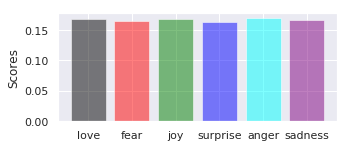

「AI」- LEVELED: Emotion Classification : Long Short Term Memory Updated


In [20]:
# EXPAND todo add last pair trust, disgust
visualize_attention()
print('「AI」- LEVELED: Emotion Classification : Long Short Term Memory Updated')

In [21]:
def pre(fragment):
    tokens = fragment.lower().split()
    for i, token in enumerate(tokens):
        if token in PRES:
            tokens[i] = PRES[token]
            pre_statement = ' '.join(tokens)
            print('\033[41m「AI」- PRE: ' + tokens[i] + ' = ' + PRES[token]+ '\033[0m')

    pre_statement = ' '.join(tokens)
    print('\033[41m「AI」- PRE: ' + pre_statement + '\033[0m')
    return pre_statement

In [22]:
#    synPatterns = {}  
#    if ((global.SYNONS) && (typeof SYNONS == 'object')) {
#        for (var i in SYNONS) synPatterns[i] = '(' + i + '|' + SYNONS[i].join('|') + ')';
#        }

def synon(fragment):
    tokens = fragment.lower().split()
    for i, token in enumerate(tokens):
        for x, pattern in SYNONS:
            if token in pattern:
                tokens[i] = SYNONS[token]
                print('\033[42;1m「AI」- SYNON: ' + tokens[i] + ' = ' + SYNONS[token] + '\033[0m')
        
        statement = ' '.join(tokens)
        return statement

In [23]:
def analyze(statement):
    # visualize_attention(statement)
    pre_statement = pre(statement)
    # synon(statement) 
    
    for pattern, responses in KEYWORDS:
        match = re.match(pattern, pre_statement.rstrip(".!"))
        if match:
            response = random.choice(responses)
            print('\033[1;42m「AI」- MATCH: ' + pattern + ' : '+ response + '\033[0m')
            return response.format(*[post(g) for g in match.groups()])
        
            # if statement == "quit":
            #     break

In [24]:
def post(fragment):
    tokens = fragment.lower().split()
    for i, token in enumerate(tokens):
        if token in POSTS:
            tokens[i] = POSTS[token]
            print('\033[1;44m「AI」- POST: ' + tokens[i] + ' = ' + POSTS[token] + '\033[0m')
    return ' '.join(tokens)

In [25]:
def talk_to_me():
    greeting = random.choice(INITIALS)
    print(greeting)

    while True:
        statement = input("> ")
        print(analyze(statement))

In [26]:
if __name__ == "__main__":
    talk_to_me()

Please tell me what's been bothering you.


StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.